<a href="https://colab.research.google.com/github/Forla03/Deep-Learning-Project---July-2026/blob/main/Deep_Learning_Project_July_Forlani_Francesco.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# SETUP

from __future__ import annotations

import json
import os
import random
import shutil
import subprocess
import sys
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras

print("TensorFlow:", tf.__version__)

I0000 00:00:1783553184.714439 1914431 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1783553185.542336 1914431 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1783553188.720559 1914431 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow: 2.21.0


In [ ]:
# CONFIG

@dataclass(frozen=True)
class Config:
    TRAIN_CSV_PATH: str = "data/white_to_black_train.csv"
    TEST_CSV_PATH: str = "data/white_to_black_test.csv"
    ARTIFACT_DIR: str = "artifacts"

    TRAIN_GDRIVE_ID: str = "1aQF9QQO0GgNLgv13bf5BfExaVij2OowX"
    TEST_GDRIVE_ID: str = "1z6ik6MyTjZLVvdsCKTFAgsL6uiSbeKs6"

    MAX_LEN: int = 60
    WHITE_VOCAB_SIZE: int = 20_000
    BLACK_VOCAB_SIZE: int = 20_000

    EMBEDDING_DIM: int = 128
    RNN_UNITS: int = 384
    BOTTLENECK_DIM: int = 256
    DROPOUT: float = 0.25
    SPATIAL_DROPOUT: float = 0.10

    BATCH_SIZE: int = 32
    PREDICTION_BATCH_SIZE: int = 16
    EPOCHS: int = 60
    VALIDATION_FRACTION: float = 0.10
    LEARNING_RATE: float = 1e-3

    SEED: int = 42

    BEST_WEIGHTS_NAME: str = "white_to_black_seq2seq_best.weights.h5"
    FINAL_WEIGHTS_NAME: str = "white_to_black_seq2seq_final.weights.h5"
    METADATA_NAME: str = "white_to_black_seq2seq_metadata.json"


CFG = Config()

In [3]:
# RUNTIME

def set_reproducibility(seed: int) -> None:
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)


def configure_runtime() -> None:
    gpus = tf.config.list_physical_devices("GPU")

    if gpus:
        keras.mixed_precision.set_global_policy("mixed_float16")
        print(f"GPU detected: {gpus[0].name}")
        print("Mixed precision enabled.")
    else:
        print("No GPU detected. Training will work, but it will be slower.")


set_reproducibility(CFG.SEED)
configure_runtime()

GPU detected: /physical_device:GPU:0
Mixed precision enabled.


W0000 00:00:1783553191.029627 1914431 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.


In [4]:
# DATASET DOWNLOAD (Decomment if you're using colab)
#
# def install_gdown() -> None:
#     try:
#         import gdown  # noqa: F401
#     except ImportError:
#         subprocess.run(
#             [sys.executable, "-m", "pip", "install", "-q", "gdown"],
#             check=True,
#         )
#
#
# def download_from_gdrive_if_needed(file_id: str, output_path: str) -> None:
#     target = Path(output_path)
#
#     if target.exists():
#         print(f"Already exists: {target}")
#         return
#
#     install_gdown()
#     target.parent.mkdir(parents=True, exist_ok=True)
#
#     url = f"https://drive.google.com/uc?id={file_id}"
#
#     subprocess.run(
#         ["gdown", url, "-O", str(target)],
#         check=True,
#     )
#
#     print(f"Downloaded: {target}")
#
#
# def ensure_dataset_files(cfg: Config) -> None:
#     download_from_gdrive_if_needed(
#         cfg.TRAIN_GDRIVE_ID,
#         cfg.TRAIN_CSV_PATH,
#     )
#
#     download_from_gdrive_if_needed(
#         cfg.TEST_GDRIVE_ID,
#         cfg.TEST_CSV_PATH,
#     )
#
#     print("CSV files in /content:")
#     for path in Path("/content").glob("*.csv"):
#         print(path)
#
#
# ensure_dataset_files(CFG)

In [5]:
# LOAD AND CLEAN

def load_and_clean_csv(path: str) -> pd.DataFrame:
    csv_path = Path(path)

    if not csv_path.exists():
        raise FileNotFoundError(f"File not found: {csv_path}")

    df = pd.read_csv(csv_path)

    required_columns = {"white", "black"}
    missing_columns = required_columns.difference(df.columns)

    if missing_columns:
        raise ValueError(f"Missing required columns in {path}: {sorted(missing_columns)}")

    df = df[["white", "black"]].dropna().copy()

    df["white"] = df["white"].astype(str).str.strip()
    df["black"] = df["black"].astype(str).str.strip()

    df = df[(df["white"] != "") & (df["black"] != "")].copy()

    white_lengths = df["white"].str.split().str.len()
    black_lengths = df["black"].str.split().str.len()

    df = df[white_lengths == black_lengths].reset_index(drop=True)

    if df.empty:
        raise ValueError(f"No valid rows after cleaning {path}.")

    return df


def load_data(cfg: Config) -> tuple[pd.DataFrame, pd.DataFrame]:
    train_df = load_and_clean_csv(cfg.TRAIN_CSV_PATH)
    test_df = load_and_clean_csv(cfg.TEST_CSV_PATH)

    print(f"Train rows: {len(train_df):,}")
    print(f"Test rows:  {len(test_df):,}")
    print("Average train length:", round(train_df["white"].str.split().str.len().mean(), 2))

    return train_df, test_df


train_df, test_df = load_data(CFG)

display(train_df.head())
display(test_df.head())

Train rows: 101,364
Test rows:  17,888
Average train length: 33.18


,white,black
0,e4 d4 Bd3 Qe2 c4 Nc3 h4 Bf4 Qd2 Nf3 Rh3 Bxh6 R...,b6 Bb7 Nf6 e6 Be7 O-O h6 d6 Ng4 Nd7 e5 Nxh6 Bx...
1,e4 d4 e5 Nf3 c3 a3 b3 cxd4 Bd2 Bc3 Be2 Nxe5 O-...,c6 e6 d5 c5 Nc6 Qb6 cxd4 Qa5+ Qb6 f6 fxe5 Bd6 ...
2,c4 b4 cxd5 d4 Ba3 e3 Bb2 Nf3 Ne5 Nxd7 Bb5 O-O ...,c6 d5 cxd5 a5 e6 axb4 Bd7 Bd6 Nc6 Qxd7 Nge7 O-...
3,e4 Nf3 d4 c3 e5 Bb5 Qa4 Bxc6+ gxf3 e6+ Qxc6+ c...,Nc6 e5 exd4 d5 Bg4 f6 Bxf3 Kf7 bxc6 Kxe6 Kf7 B...
4,e4 f3 d3 e5 f4 exf6 c3 b4 Nh3 g4 gxf5 Ng5 Ne6 ...,Nf6 d5 e6 Nfd7 f6 Bb4+ Ba5 Bb6 gxf6 f5 exf5 h6...


,white,black
0,e3 Qf3 e4 exd5 Bc4 Nc3 Ne4 Bxe6 Nxf6+ Qh5+ Qg4...,d5 e5 Nf6 Nxd5 Nf6 c6 Be6 fxe6 Qxf6 g6 Nd7 Bc5...
1,d4 c4 Nc3 e4 Bd3 Nge2 O-O f4 a3 fxe5 d5 Nxd4 N...,d6 e6 Nf6 g6 Bg7 O-O Nc6 Re8 e5 dxe5 Nd4 exd4 ...
2,d4 c4 Nc3 Nf3 Bg5 e3 Bd3 O-O Bxc4 Bd3 a3 Rc1 N...,Nf6 g6 d5 Bg7 c6 O-O e6 dxc4 b5 a6 Bb7 Nbd7 Rc...
3,e4 Nf3 d4 dxe5 Qxd8+ Nxe5 c3 Nc4 Be3 Be2 Nbd2 ...,e5 Nc6 d6 dxe5 Nxd8 Bb4+ Bd6 Bc5 Ne6 Nf6 b5 Nx...
4,e4 d3 Nd2 Ngf3 g3 Bg2 O-O Re1 b3 Bb2 c3 a3 b4 ...,b6 Bb7 Nf6 e6 Be7 h6 O-O d6 e5 Nbd7 c6 d5 dxe4...


count    101364.000000
mean         33.181938
std          14.227148
min           5.000000
25%          23.000000
50%          31.000000
75%          43.000000
max          60.000000
Name: white, dtype: float64


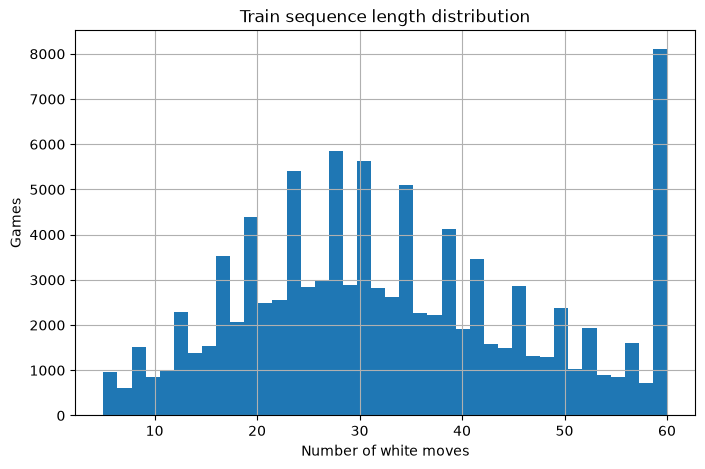

In [6]:
# LENGTH ANALYSIS

lengths = train_df["white"].str.split().str.len()

print(lengths.describe())

plt.figure(figsize=(8, 5))
plt.hist(lengths, bins=40)
plt.xlabel("Number of white moves")
plt.ylabel("Games")
plt.title("Train sequence length distribution")
plt.grid(True)
plt.show()

In [7]:
# TRAIN / VALIDATION SPLIT

def split_train_validation(
    dataframe: pd.DataFrame,
    validation_fraction: float,
    seed: int,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    shuffled = dataframe.sample(frac=1.0, random_state=seed).reset_index(drop=True)
    val_size = max(1, int(len(shuffled) * validation_fraction))

    val_df = shuffled.iloc[:val_size].reset_index(drop=True)
    fit_df = shuffled.iloc[val_size:].reset_index(drop=True)

    return fit_df, val_df


fit_df, val_df = split_train_validation(
    train_df,
    validation_fraction=CFG.VALIDATION_FRACTION,
    seed=CFG.SEED,
)

print(f"Fit rows:        {len(fit_df):,}")
print(f"Validation rows: {len(val_df):,}")

Fit rows:        91,228
Validation rows: 10,136


In [8]:
# VECTORIZERS

def create_vectorizer(
    max_tokens: int,
    max_len: int,
    name: str,
) -> keras.layers.TextVectorization:
    return keras.layers.TextVectorization(
        max_tokens=max_tokens,
        standardize=None,
        split="whitespace",
        output_mode="int",
        output_sequence_length=max_len,
        name=name,
    )


def adapt_vectorizers(
    dataframe: pd.DataFrame,
    cfg: Config,
) -> tuple[keras.layers.TextVectorization, keras.layers.TextVectorization]:
    white_vectorizer = create_vectorizer(
        max_tokens=cfg.WHITE_VOCAB_SIZE,
        max_len=cfg.MAX_LEN,
        name="white_vectorizer",
    )

    black_vectorizer = create_vectorizer(
        max_tokens=cfg.BLACK_VOCAB_SIZE,
        max_len=cfg.MAX_LEN,
        name="black_vectorizer",
    )

    white_ds = tf.data.Dataset.from_tensor_slices(
        dataframe["white"].to_numpy()
    ).batch(1024)

    black_ds = tf.data.Dataset.from_tensor_slices(
        dataframe["black"].to_numpy()
    ).batch(1024)

    white_vectorizer.adapt(white_ds)
    black_vectorizer.adapt(black_ds)

    print(f"White vocabulary size: {len(white_vectorizer.get_vocabulary()):,}")
    print(f"Black vocabulary size: {len(black_vectorizer.get_vocabulary()):,}")

    return white_vectorizer, black_vectorizer


white_vectorizer, black_vectorizer = adapt_vectorizers(train_df, CFG)

black_vocabulary = black_vectorizer.get_vocabulary()
BLACK_VOCAB_SIZE_EFF = len(black_vocabulary)
START_ID = BLACK_VOCAB_SIZE_EFF

print("Effective black vocabulary size:", BLACK_VOCAB_SIZE_EFF)
print("START_ID:", START_ID)

W0000 00:00:1783553195.903788 1914431 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1783553196.523254 1914431 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5144 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 12.0a


White vocabulary size: 4,363
Black vocabulary size: 5,115
Effective black vocabulary size: 5115
START_ID: 5115


In [9]:
# TENSORFLOW DATASET

def make_decoder_input(
    y: np.ndarray,
    start_id: int,
) -> np.ndarray:
    start_column = np.full(
        shape=(y.shape[0], 1),
        fill_value=start_id,
        dtype="int32",
    )

    return np.concatenate(
        [start_column, y[:, :-1]],
        axis=1,
    )


def vectorize_dataframe(
    dataframe: pd.DataFrame,
    white_vectorizer: keras.layers.TextVectorization,
    black_vectorizer: keras.layers.TextVectorization,
    start_id: int,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    x_white = white_vectorizer(
        tf.constant(dataframe["white"].to_numpy())
    ).numpy().astype("int32")

    y = black_vectorizer(
        tf.constant(dataframe["black"].to_numpy())
    ).numpy().astype("int32")

    x_black_shifted = make_decoder_input(
        y=y,
        start_id=start_id,
    )

    sample_weight = (y != 0).astype("float32")

    return x_white, x_black_shifted, y, sample_weight


def make_dataset(
    x_white: np.ndarray,
    x_black_shifted: np.ndarray,
    y: np.ndarray,
    sample_weight: np.ndarray,
    batch_size: int,
    shuffle: bool,
    seed: int,
) -> tf.data.Dataset:
    dataset = tf.data.Dataset.from_tensor_slices(
        (
            {
                "white_tokens": x_white,
                "black_tokens_shifted": x_black_shifted,
            },
            y,
            sample_weight,
        )
    )

    if shuffle:
        dataset = dataset.shuffle(
            buffer_size=min(len(x_white), 20_000),
            seed=seed,
            reshuffle_each_iteration=True,
        )

    return dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)


x_train_white, x_train_black_shifted, y_train, sw_train = vectorize_dataframe(
    dataframe=fit_df,
    white_vectorizer=white_vectorizer,
    black_vectorizer=black_vectorizer,
    start_id=START_ID,
)

x_val_white, x_val_black_shifted, y_val, sw_val = vectorize_dataframe(
    dataframe=val_df,
    white_vectorizer=white_vectorizer,
    black_vectorizer=black_vectorizer,
    start_id=START_ID,
)

train_ds = make_dataset(
    x_white=x_train_white,
    x_black_shifted=x_train_black_shifted,
    y=y_train,
    sample_weight=sw_train,
    batch_size=CFG.BATCH_SIZE,
    shuffle=True,
    seed=CFG.SEED,
)

val_ds = make_dataset(
    x_white=x_val_white,
    x_black_shifted=x_val_black_shifted,
    y=y_val,
    sample_weight=sw_val,
    batch_size=CFG.BATCH_SIZE,
    shuffle=False,
    seed=CFG.SEED,
)

print("x_train_white:", x_train_white.shape)
print("x_train_black_shifted:", x_train_black_shifted.shape)
print("y_train:", y_train.shape)

x_train_white: (91228, 60)
x_train_black_shifted: (91228, 60)
y_train: (91228, 60)


In [10]:
# MODEL

def build_seq2seq_model(
    white_vocab_size: int,
    black_vocab_size: int,
    cfg: Config,
) -> tuple[keras.Model, keras.Model]:
    encoder_inputs = keras.Input(
        shape=(cfg.MAX_LEN,),
        dtype="int32",
        name="white_tokens",
    )

    enc_emb = keras.layers.Embedding(
        input_dim=white_vocab_size,
        output_dim=cfg.EMBEDDING_DIM,
        mask_zero=True,
        name="white_embedding",
    )(encoder_inputs)

    enc_emb = keras.layers.SpatialDropout1D(
        cfg.SPATIAL_DROPOUT,
        name="encoder_embedding_dropout",
    )(enc_emb)

    encoder_outputs, fwd_h, bwd_h = keras.layers.Bidirectional(
        keras.layers.GRU(
            cfg.RNN_UNITS,
            return_sequences=True,
            return_state=True,
            dropout=cfg.DROPOUT,
            recurrent_dropout=0.0,
        ),
        name="encoder_bigru",
    )(enc_emb)

    encoder_state = keras.layers.Concatenate(
        name="encoder_state_concat"
    )([fwd_h, bwd_h])

    decoder_init_state = keras.layers.Dense(
        cfg.RNN_UNITS,
        activation="tanh",
        name="decoder_init",
    )(encoder_state)

    decoder_inputs = keras.Input(
        shape=(cfg.MAX_LEN,),
        dtype="int32",
        name="black_tokens_shifted",
    )

    dec_emb = keras.layers.Embedding(
        input_dim=black_vocab_size + 1,
        output_dim=cfg.EMBEDDING_DIM,
        name="black_embedding",
    )(decoder_inputs)

    decoder_gru_input = keras.layers.Concatenate(
        axis=-1,
        name="decoder_gru_input",
    )([dec_emb, encoder_outputs])

    decoder_seq, _ = keras.layers.GRU(
        cfg.RNN_UNITS,
        return_sequences=True,
        return_state=True,
        dropout=cfg.DROPOUT,
        recurrent_dropout=0.0,
        name="decoder_gru",
    )(
        decoder_gru_input,
        initial_state=decoder_init_state,
    )

    x = keras.layers.Dense(
        cfg.BOTTLENECK_DIM,
        activation="gelu",
        name="move_bottleneck",
    )(decoder_seq)

    x = keras.layers.Dropout(
        cfg.DROPOUT,
        name="bottleneck_dropout",
    )(x)

    outputs = keras.layers.Dense(
        black_vocab_size,
        activation="softmax",
        dtype="float32",
        name="black_move",
    )(x)

    model = keras.Model(
        inputs=[encoder_inputs, decoder_inputs],
        outputs=outputs,
        name="white_to_black_seq2seq_teacher_forcing",
    )

    encoder_model = keras.Model(
        inputs=encoder_inputs,
        outputs=[encoder_outputs, decoder_init_state],
        name="white_to_black_encoder",
    )

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=cfg.LEARNING_RATE,
            clipnorm=1.0,
        ),
        loss=keras.losses.SparseCategoricalCrossentropy(),
        metrics=[
            keras.metrics.SparseCategoricalAccuracy(name="token_acc"),
        ],
    )

    return model, encoder_model


def count_trainable_parameters(model: keras.Model) -> int:
    return int(
        np.sum([
            np.prod(weight.shape)
            for weight in model.trainable_weights
        ])
    )


def assert_parameter_budget(
    model: keras.Model,
    max_trainable_params: int = 6_000_000,
) -> None:
    trainable_params = count_trainable_parameters(model)

    print(f"Trainable parameters: {trainable_params:,}")

    if trainable_params >= max_trainable_params:
        raise ValueError(
            f"Model has {trainable_params:,} trainable parameters. "
            f"It must stay below {max_trainable_params:,}."
        )


model, encoder_model = build_seq2seq_model(
    white_vocab_size=len(white_vectorizer.get_vocabulary()),
    black_vocab_size=len(black_vectorizer.get_vocabulary()),
    cfg=CFG,
)

model.summary()
assert_parameter_budget(model)

Model: "white_to_black_seq2seq_teacher_forcing"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ white_tokens        │ (None, 60)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ white_embedding     │ (None, 60, 128)   │    558,464 │ white_tokens[0][… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_embedding_… │ (None, 60, 128)   │          0 │ white_embedding[… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 60)        │          0 │ white_tokens[0][… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ black_tokens_shift… │ (None, 60)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_bigru       │ [(None, 60, 768), │  1,184,256 │ encoder_embeddin… │
│ (Bidirectional)     │ (None, 384),      │            │ not_equal[0][0]   │
│                     │ (None, 384)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ black_embedding     │ (None, 60, 128)   │    654,848 │ black_tokens_shi… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_state_conc… │ (None, 768)       │          0 │ encoder_bigru[0]… │
│ (Concatenate)       │                   │            │ encoder_bigru[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_gru_input   │ (None, 60, 896)   │          0 │ black_embedding[… │
│ (Concatenate)       │                   │            │ encoder_bigru[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_init        │ (None, 384)       │    295,296 │ encoder_state_co… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_gru (GRU)   │ [(None, 60, 384), │  1,476,864 │ decoder_gru_inpu… │
│                     │ (None, 384)]      │            │ decoder_init[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ move_bottleneck     │ (None, 60, 256)   │     98,560 │ decoder_gru[0][0] │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bottleneck_dropout  │ (None, 60, 256)   │          0 │ move_bottleneck[… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ black_move (Dense)  │ (None, 60, 5115)  │  1,314,555 │ bottleneck_dropo… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,582,843 (21.30 MB)

 Trainable params: 5,582,843 (21.30 MB)

 Non-trainable params: 0 (0.00 B)

Trainable parameters: 5,582,843


In [ ]:
#TRAINING

def train_model(
    model: keras.Model,
    train_ds: tf.data.Dataset,
    val_ds: tf.data.Dataset,
    cfg: Config,
) -> keras.callbacks.History:
    artifact_dir = Path(cfg.ARTIFACT_DIR)
    artifact_dir.mkdir(parents=True, exist_ok=True)

    best_weights_path = artifact_dir / cfg.BEST_WEIGHTS_NAME

    callbacks = [
        keras.callbacks.ModelCheckpoint(
            filepath=str(best_weights_path),
            monitor="val_loss",
            save_best_only=True,
            save_weights_only=True,
            mode="min",
            verbose=1,
        ),
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            min_delta=1e-4,
            patience=4,
            restore_best_weights=True,
            mode="min",
            verbose=1,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            min_delta=1e-4,
            factor=0.5,
            patience=2,
            min_lr=1e-5,
            mode="min",
            verbose=1,
        ),
    ]

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=cfg.EPOCHS,
        callbacks=callbacks,
    )

    if best_weights_path.exists():
        model.load_weights(str(best_weights_path))

    return history


history = train_model(model, train_ds, val_ds, CFG)

Epoch 1/60


/home/francesco/chess_project/Deep-Learning-Project---July-2026/.venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
E0000 00:00:1783553210.727019 1914431 util.cc:131] oneDNN supports DT_HALF only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.
I0000 00:00:1783553213.507758 1915078 cuda_dnn.cc:461] Loaded cuDNN version 92400


404/713 ━━━━━━━━━━━━━━━━━━━━ 1:32 300ms/step - loss: 3.1546 - token_acc: 0.0232
Epoch 1: val_loss improved from None to 2.72135, saving model to artifacts/white_to_black_seq2seq_best.weights.h5

Epoch 1: finished saving model to artifacts/white_to_black_seq2seq_best.weights.h5
713/713 ━━━━━━━━━━━━━━━━━━━━ 115s 138ms/step - loss: 3.0362 - token_acc: 0.0316 - val_loss: 2.7214 - val_token_acc: 0.0565 - learning_rate: 0.0010
Epoch 2/60
673/713 ━━━━━━━━━━━━━━━━━━━━ 9s 234ms/step - loss: 2.4818 - token_acc: 0.0824 
Epoch 2: val_loss improved from 2.72135 to 2.16746, saving model to artifacts/white_to_black_seq2seq_best.weights.h5

Epoch 2: finished saving model to artifacts/white_to_black_seq2seq_best.weights.h5
713/713 ━━━━━━━━━━━━━━━━━━━━ 99s 139ms/step - loss: 2.4683 - token_acc: 0.0839 - val_loss: 2.1675 - val_token_acc: 0.1220 - learning_rate: 0.0010
Epoch 3/60
616/713 ━━━━━━━━━━━━━━━━━━━━ 23s 241ms/step - loss: 2.1157 - token_acc: 0.1282
Epoch 3: val_loss improved from 2.16746 to 1.905

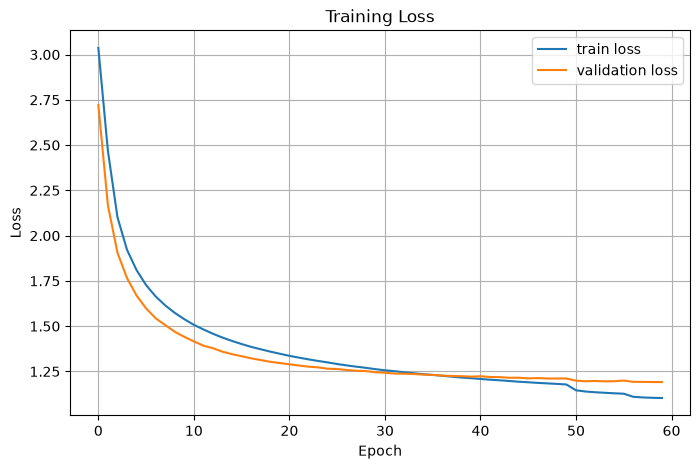

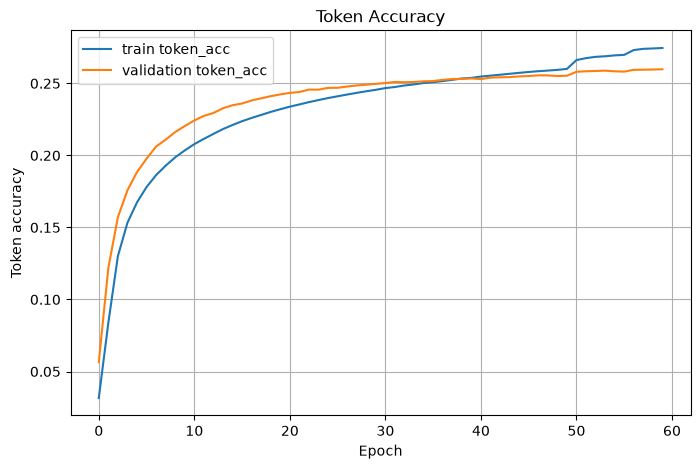

In [12]:
# TRAINING PLOTS

history_df = pd.DataFrame(history.history)

plt.figure(figsize=(8, 5))
plt.plot(history_df["loss"], label="train loss")
plt.plot(history_df["val_loss"], label="validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_df["token_acc"], label="train token_acc")
plt.plot(history_df["val_token_acc"], label="validation token_acc")
plt.xlabel("Epoch")
plt.ylabel("Token accuracy")
plt.title("Token Accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [13]:
# INFERENCE

def ids_to_tokens(
    ids: list[int],
    vocabulary: list[str],
    limit: int,
) -> list[str]:
    decoded: list[str] = []

    for token_id in ids[:limit]:
        token_id = int(token_id)

        if token_id <= 0 or token_id >= len(vocabulary):
            break

        token = vocabulary[token_id]

        if token == "":
            break

        decoded.append(token)

    return decoded


def get_decoder_layers(
    model: keras.Model,
) -> tuple[
    keras.layers.Embedding,
    keras.layers.GRU,
    keras.layers.Dense,
    keras.layers.Dropout,
    keras.layers.Dense,
]:
    black_embedding = model.get_layer("black_embedding")
    decoder_gru = model.get_layer("decoder_gru")
    bottleneck_dense = model.get_layer("move_bottleneck")
    bottleneck_dropout = model.get_layer("bottleneck_dropout")
    output_dense = model.get_layer("black_move")

    return (
        black_embedding,
        decoder_gru,
        bottleneck_dense,
        bottleneck_dropout,
        output_dense,
    )


def generate_black_moves_batch(
    white_texts: list[str],
    model: keras.Model,
    encoder_model: keras.Model,
    white_vectorizer: keras.layers.TextVectorization,
    black_vocabulary: list[str],
    cfg: Config,
    start_id: int,
) -> list[list[str]]:
    (
        black_embedding,
        decoder_gru,
        bottleneck_dense,
        bottleneck_dropout,
        output_dense,
    ) = get_decoder_layers(model)

    x_white = white_vectorizer(
        tf.constant(white_texts)
    ).numpy().astype("int32")

    batch_size = x_white.shape[0]

    white_lengths = np.array([
        min(len(text.split()), cfg.MAX_LEN)
        for text in white_texts
    ])

    encoder_outputs, state = encoder_model(
        x_white,
        training=False,
    )

    prev_token = tf.fill(
        dims=(batch_size, 1),
        value=tf.constant(start_id, dtype=tf.int32),
    )

    generated_ids: list[list[int]] = [
        []
        for _ in range(batch_size)
    ]

    finished = np.zeros(batch_size, dtype=bool)

    for timestep in range(cfg.MAX_LEN):
        for sample_index in range(batch_size):
            if timestep >= white_lengths[sample_index]:
                finished[sample_index] = True

        if finished.all():
            break

        emb = black_embedding(prev_token)
        emb = emb[:, 0, :]

        enc_t = encoder_outputs[:, timestep, :]

        step_input = tf.concat(
            [emb, enc_t],
            axis=-1,
        )

        cell_output, new_states = decoder_gru.cell(
            step_input,
            states=[state],
            training=False,
        )

        state = new_states[0]

        h = bottleneck_dense(cell_output)
        h = bottleneck_dropout(h, training=False)

        probabilities = output_dense(h).numpy()
        predicted_ids = np.argmax(probabilities, axis=-1).astype("int32")

        for sample_index in range(batch_size):
            if finished[sample_index]:
                continue

            token_id = int(predicted_ids[sample_index])

            if token_id <= 0 or token_id >= len(black_vocabulary):
                finished[sample_index] = True
                continue

            token = black_vocabulary[token_id]

            if token == "":
                finished[sample_index] = True
                continue

            generated_ids[sample_index].append(token_id)

        prev_token = tf.constant(
            predicted_ids.reshape(-1, 1),
            dtype=tf.int32,
        )

    decoded_batch = [
        ids_to_tokens(
            ids=ids,
            vocabulary=black_vocabulary,
            limit=white_lengths[index],
        )
        for index, ids in enumerate(generated_ids)
    ]

    return decoded_batch


def predict_black_moves_batch(
    model: keras.Model,
    encoder_model: keras.Model,
    white_texts: list[str],
    white_vectorizer: keras.layers.TextVectorization,
    black_vocabulary: list[str],
    cfg: Config,
    start_id: int,
) -> list[list[str]]:
    return generate_black_moves_batch(
        white_texts=white_texts,
        model=model,
        encoder_model=encoder_model,
        white_vectorizer=white_vectorizer,
        black_vocabulary=black_vocabulary,
        cfg=cfg,
        start_id=start_id,
    )


def predict_black_moves(
    model: keras.Model,
    encoder_model: keras.Model,
    white_text: str,
    white_vectorizer: keras.layers.TextVectorization,
    black_vocabulary: list[str],
    cfg: Config,
    start_id: int,
) -> list[str]:
    return predict_black_moves_batch(
        model=model,
        encoder_model=encoder_model,
        white_texts=[white_text],
        white_vectorizer=white_vectorizer,
        black_vocabulary=black_vocabulary,
        cfg=cfg,
        start_id=start_id,
    )[0]

In [14]:
# SURVIVAL AUC

def correct_prefix_length(
    true_tokens: list[str],
    predicted_tokens: list[str],
) -> int:
    correct = 0

    for true_token, predicted_token in zip(
        true_tokens,
        predicted_tokens,
        strict=False,
    ):
        if true_token != predicted_token:
            break

        correct += 1

    return correct


def batched_ranges(
    length: int,
    batch_size: int,
) -> list[tuple[int, int]]:
    return [
        (start, min(start + batch_size, length))
        for start in range(0, length, batch_size)
    ]


def evaluate_survival_auc(
    dataframe: pd.DataFrame,
    model: keras.Model,
    encoder_model: keras.Model,
    white_vectorizer: keras.layers.TextVectorization,
    black_vocabulary: list[str],
    cfg: Config,
    start_id: int,
    max_examples: int | None = None,
) -> dict[str, Any]:
    eval_df = dataframe if max_examples is None else dataframe.head(max_examples)
    eval_df = eval_df.reset_index(drop=True)

    prefix_lengths: list[int] = []

    token_correct = 0
    token_total = 0
    first_move_correct = 0
    exact_sequence_correct = 0

    for start, end in batched_ranges(
        len(eval_df),
        cfg.PREDICTION_BATCH_SIZE,
    ):
        batch = eval_df.iloc[start:end]

        predictions = predict_black_moves_batch(
            model=model,
            encoder_model=encoder_model,
            white_texts=batch["white"].tolist(),
            white_vectorizer=white_vectorizer,
            black_vocabulary=black_vocabulary,
            cfg=cfg,
            start_id=start_id,
        )

        for true_text, predicted_tokens in zip(
            batch["black"].tolist(),
            predictions,
            strict=False,
        ):
            true_tokens = true_text.split()[:cfg.MAX_LEN]
            predicted_tokens = predicted_tokens[:len(true_tokens)]

            prefix_len = correct_prefix_length(
                true_tokens=true_tokens,
                predicted_tokens=predicted_tokens,
            )

            prefix_lengths.append(prefix_len)

            first_move_correct += int(prefix_len >= 1)
            exact_sequence_correct += int(prefix_len == len(true_tokens))

            for true_token, predicted_token in zip(
                true_tokens,
                predicted_tokens,
                strict=False,
            ):
                token_correct += int(true_token == predicted_token)
                token_total += 1

    max_curve_len = min(
        cfg.MAX_LEN,
        max((len(text.split()) for text in eval_df["black"]), default=0),
    )

    survival_curve = {
        int(k): float(np.mean([
            prefix_len >= k
            for prefix_len in prefix_lengths
        ]))
        for k in range(1, max_curve_len + 1)
    }

    survival_auc = float(np.mean(prefix_lengths)) if prefix_lengths else 0.0

    return {
        "n_examples": int(len(eval_df)),
        "survival_auc": survival_auc,
        "mean_correct_prefix": survival_auc,
        "first_move_accuracy": (
            float(first_move_correct / len(eval_df))
            if len(eval_df)
            else 0.0
        ),
        "exact_sequence_accuracy": (
            float(exact_sequence_correct / len(eval_df))
            if len(eval_df)
            else 0.0
        ),
        "token_accuracy": (
            float(token_correct / token_total)
            if token_total
            else 0.0
        ),
        "survival_curve": survival_curve,
        "prefix_lengths": prefix_lengths,
    }


def print_metrics(metrics: dict[str, Any]) -> None:
    print(f"Examples:                {metrics['n_examples']:,}")
    print(f"Survival AUC:            {metrics['survival_auc']:.4f}")
    print(f"First move accuracy:     {metrics['first_move_accuracy']:.4f}")
    print(f"Token accuracy:          {metrics['token_accuracy']:.4f}")
    print(f"Exact sequence accuracy: {metrics['exact_sequence_accuracy']:.4f}")


def plot_survival_curve(metrics: dict[str, Any]) -> None:
    curve = metrics["survival_curve"]

    if not curve:
        print("No survival curve available.")
        return

    plt.figure(figsize=(8, 5))
    plt.plot(list(curve.keys()), list(curve.values()), marker="o")
    plt.xlabel("k")
    plt.ylabel("S(k)")
    plt.title("Survival Curve")
    plt.grid(True)
    plt.show()

Validation metrics with seq2seq teacher forcing
Examples:                10,136
Survival AUC:            2.1728
First move accuracy:     0.6695
Token accuracy:          0.2349
Exact sequence accuracy: 0.0017


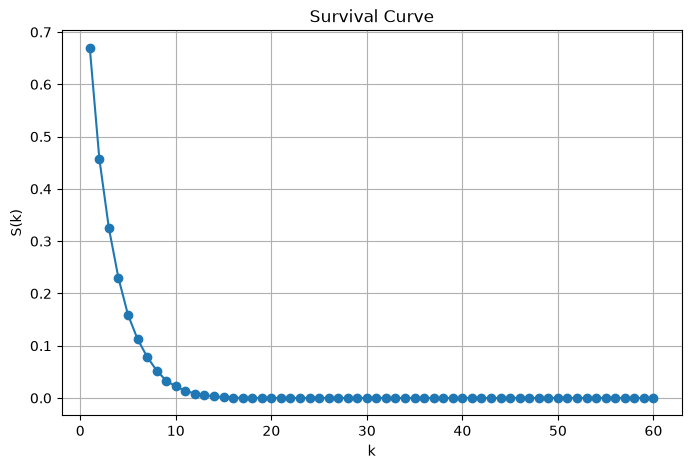

In [15]:
# FINAL VALIDATION

print("Validation metrics with seq2seq teacher forcing")

val_metrics = evaluate_survival_auc(
    dataframe=val_df,
    model=model,
    encoder_model=encoder_model,
    white_vectorizer=white_vectorizer,
    black_vocabulary=black_vocabulary,
    cfg=CFG,
    start_id=START_ID,
    max_examples=None,
)

print_metrics(val_metrics)
plot_survival_curve(val_metrics)


Full test metrics with seq2seq teacher forcing


Examples:                17,888
Survival AUC:            2.1965
First move accuracy:     0.6622
Token accuracy:          0.2368
Exact sequence accuracy: 0.0012


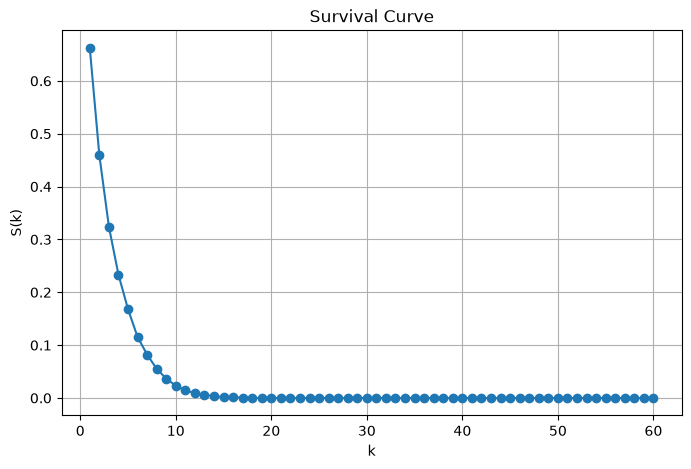

In [16]:
# FINAL TEST

print("\nFull test metrics with seq2seq teacher forcing")

test_metrics = evaluate_survival_auc(
    dataframe=test_df,
    model=model,
    encoder_model=encoder_model,
    white_vectorizer=white_vectorizer,
    black_vocabulary=black_vocabulary,
    cfg=CFG,
    start_id=START_ID,
    max_examples=None,
)

print_metrics(test_metrics)
plot_survival_curve(test_metrics)

In [17]:
# QUALITY EXAMPLES

sample_df = test_df.sample(
    n=min(5, len(test_df)),
    random_state=CFG.SEED,
)

for _, row in sample_df.iterrows():
    predicted_black = predict_black_moves(
        model=model,
        encoder_model=encoder_model,
        white_text=row["white"],
        white_vectorizer=white_vectorizer,
        black_vocabulary=black_vocabulary,
        cfg=CFG,
        start_id=START_ID,
    )

    print("=" * 100)
    print("White:      ", row["white"])
    print("True black: ", row["black"])
    print("Pred black: ", " ".join(predicted_black))

White:       e4 Nf3 Bb5 O-O c3 Ba4 Bb3 Bc2 Re1 h3 d4 Qxf3 d5 b4 Bg5 Nd2 cxb4 Nf1 bxc5 Ng3 Be3 Nf5 Nxe7 Qf5+ Qf3 Qg3
True black:  e5 Nc6 d6 Bd7 a6 b5 Na5 Nf6 Bg4 Bh5 Bxf3 Be7 O-O Nb7 a5 axb4 Qd7 c5 Nxc5 h6 b4 Kh7 Qxe7 g6 Kg7 Nfxe4
Pred black:  e5 Nc6 Nge7 Ng6 a6 b5 Na5 d6 Bg4 Bh5 Bxf3 Be7 c5 Nb7 a5 axb4 O-O h6 Nxc5 Nh7 f6 Kh7 Qxe7 Kh8 Ng5 Nxe4
White:       e4 Nf3 Nc3 d4 Nxd4 Nxc6 Qd4 Be3 Bxd4 e5 Nxd5 Bd3 Be3 Be4 Bc1 O-O f4 exd6 Bc6 Ba4 Rf2 b3 Rf1 Rxe1 Kf2 Kg3 Bb2 Bxa1 Bd7 Kg4 h3 Bf5 Kxh5 c3
True black:  e5 Nc6 Nf6 exd4 Qe7 bxc6 Qc5 Qxd4 Be7 Nd5 cxd5 c5 d4 Rb8 O-O Re8 d6 Bxd6 Re2 Bb7 Rbe8 Re1+ R8e2 Rxe1+ Rh1 Rg1 Rxa1 g5 Bxf4+ Bxg2 Be4 h5+ Bxf5 d3
Pred black:  c5 Nc6 g6 cxd4 Bg7 bxc6 Qb6 Bxd4 Nf6 Nd5 cxd5 O-O d4 Qxb2 Qxa2 d6 d5 exd6 Ba6 Be2 d3 dxe2 e1=Q+ Qxe1+ Qd4+ Qxb2 Qxa1 Qxa2 Qe1+ h5 a5 gxf5+ a4 a3
White:       d4 c4 e3 cxd5 Nc3 a3 b4 Bb2 Nf3 Qc2 Bd3 Ng5 h3 f4 g4 hxg4 Be2 Nd1 Nxe3 Bc1 Qxc6 Qxa8+ Rxc1 axb4 Kf1 Qb7 Ke1 Bd1 Qxd5 Be2 Qd2 Kd1 Kc2 Qd4+ Qd2+ Qc3 Bd3 Kb3 Qc1+ Qxh1+ Qc6 Qd7+
T

In [18]:
# ARTIFACTS SAVING

def extract_metric_summary(metrics: dict[str, Any]) -> dict[str, float]:
    return {
        "survival_auc": float(metrics["survival_auc"]),
        "first_move_accuracy": float(metrics["first_move_accuracy"]),
        "token_accuracy": float(metrics["token_accuracy"]),
        "exact_sequence_accuracy": float(metrics["exact_sequence_accuracy"]),
    }


def save_artifacts(
    model: keras.Model,
    white_vectorizer: keras.layers.TextVectorization,
    black_vectorizer: keras.layers.TextVectorization,
    cfg: Config,
    start_id: int,
    val_metrics: dict[str, Any] | None = None,
    test_metrics: dict[str, Any] | None = None,
) -> tuple[Path, Path]:
    artifact_dir = Path(cfg.ARTIFACT_DIR)
    artifact_dir.mkdir(parents=True, exist_ok=True)

    final_weights_path = artifact_dir / cfg.FINAL_WEIGHTS_NAME
    metadata_path = artifact_dir / cfg.METADATA_NAME

    model.save_weights(str(final_weights_path))

    metadata = {
        "model_type": "seq2seq_teacher_forcing",
        "config": asdict(cfg),
        "start_id": int(start_id),
        "white_vocabulary": white_vectorizer.get_vocabulary(),
        "black_vocabulary": black_vectorizer.get_vocabulary(),
        "final_metrics": {
            "validation": (
                extract_metric_summary(val_metrics)
                if val_metrics is not None
                else None
            ),
            "test": (
                extract_metric_summary(test_metrics)
                if test_metrics is not None
                else None
            ),
        },
    }

    metadata_path.write_text(
        json.dumps(metadata, ensure_ascii=False, indent=2),
        encoding="utf-8",
    )

    print(f"Saved weights:  {final_weights_path}")
    print(f"Saved metadata: {metadata_path}")

    return final_weights_path, metadata_path


final_weights_path, metadata_path = save_artifacts(
    model=model,
    white_vectorizer=white_vectorizer,
    black_vectorizer=black_vectorizer,
    cfg=CFG,
    start_id=START_ID,
    val_metrics=val_metrics,
    test_metrics=globals().get("test_metrics"),
)

Saved weights:  artifacts/white_to_black_seq2seq_final.weights.h5
Saved metadata: artifacts/white_to_black_seq2seq_metadata.json


In [19]:
# RELOAD CHECK

def load_vectorizer_from_vocabulary(
    vocabulary: list[str],
    max_tokens: int,
    max_len: int,
    name: str,
) -> keras.layers.TextVectorization:
    vectorizer = create_vectorizer(
        max_tokens=max_tokens,
        max_len=max_len,
        name=name,
    )

    vectorizer.set_vocabulary(vocabulary)

    return vectorizer


def load_config_from_metadata(metadata_config: dict[str, Any]) -> Config:
    valid_config_keys = set(Config.__dataclass_fields__.keys())

    clean_config = {
        key: value
        for key, value in metadata_config.items()
        if key in valid_config_keys
    }

    return Config(**clean_config)


def load_artifacts(
    artifact_dir: str,
    weights_name: str | None = None,
    metadata_name: str | None = None,
) -> tuple[
    keras.Model,
    keras.Model,
    keras.layers.TextVectorization,
    keras.layers.TextVectorization,
    Config,
    int,
]:
    artifact_path = Path(artifact_dir)
    metadata_path = artifact_path / (metadata_name or CFG.METADATA_NAME)

    metadata = json.loads(metadata_path.read_text(encoding="utf-8"))

    loaded_cfg = load_config_from_metadata(metadata["config"])

    if weights_name is not None:
        loaded_cfg = Config(
            **{
                **asdict(loaded_cfg),
                "FINAL_WEIGHTS_NAME": weights_name,
            }
        )

    loaded_white_vectorizer = load_vectorizer_from_vocabulary(
        vocabulary=metadata["white_vocabulary"],
        max_tokens=loaded_cfg.WHITE_VOCAB_SIZE,
        max_len=loaded_cfg.MAX_LEN,
        name="white_vectorizer",
    )

    loaded_black_vectorizer = load_vectorizer_from_vocabulary(
        vocabulary=metadata["black_vocabulary"],
        max_tokens=loaded_cfg.BLACK_VOCAB_SIZE,
        max_len=loaded_cfg.MAX_LEN,
        name="black_vectorizer",
    )

    loaded_model, loaded_encoder_model = build_seq2seq_model(
        white_vocab_size=len(metadata["white_vocabulary"]),
        black_vocab_size=len(metadata["black_vocabulary"]),
        cfg=loaded_cfg,
    )

    loaded_model.load_weights(
        str(artifact_path / loaded_cfg.FINAL_WEIGHTS_NAME)
    )

    loaded_start_id = int(metadata.get(
        "start_id",
        len(metadata["black_vocabulary"]),
    ))

    return (
        loaded_model,
        loaded_encoder_model,
        loaded_white_vectorizer,
        loaded_black_vectorizer,
        loaded_cfg,
        loaded_start_id,
    )


(
    loaded_model,
    loaded_encoder_model,
    loaded_white_vectorizer,
    loaded_black_vectorizer,
    loaded_cfg,
    loaded_start_id,
) = load_artifacts(CFG.ARTIFACT_DIR)

assert_parameter_budget(loaded_model)

print("Reload OK.")
print("Loaded artifact dir:", loaded_cfg.ARTIFACT_DIR)
print("Loaded final weights:", loaded_cfg.FINAL_WEIGHTS_NAME)
print("Loaded model type: seq2seq teacher forcing")
print("Loaded START_ID:", loaded_start_id)

Trainable parameters: 5,582,843
Reload OK.
Loaded artifact dir: artifacts
Loaded final weights: white_to_black_seq2seq_final.weights.h5
Loaded model type: seq2seq teacher forcing
Loaded START_ID: 5115


/home/francesco/chess_project/Deep-Learning-Project---July-2026/.venv/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:843: UserWarning: Skipping variable loading for optimizer 'loss_scale_optimizer', because it has 4 variables whereas the saved optimizer has 40 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/home/francesco/chess_project/Deep-Learning-Project---July-2026/.venv/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:843: UserWarning: Skipping variable loading for optimizer 'adam_1', because it has 2 variables whereas the saved optimizer has 36 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [20]:
# COPY ARTIFACTS TO GOOGLE DRIVE
# Run this cell only in Colab.

# def copy_artifacts_to_drive(
#     source_dir: str,
#     drive_target_dir: str = "/content/drive/MyDrive/chess_white_to_black_artifacts",
# ) -> None:
#     from google.colab import drive
#
#     drive.mount("/content/drive")
#
#     src = Path(source_dir)
#     dst = Path(drive_target_dir)
#
#     shutil.copytree(src, dst, dirs_exist_ok=True)
#
#     print(f"Copied artifacts to: {dst}")
#
#     for path in dst.glob("*"):
#         size_mb = round(path.stat().st_size / 1024 / 1024, 2)
#         print(path.name, size_mb, "MB")
#
#
# copy_artifacts_to_drive(CFG.ARTIFACT_DIR)